# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../../lectures/lecture01/lecture01.md), [демо](../../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ (а).** $x \in \mathbb{R}^3$ — искомая точка. Минимизируем квадрат расстояния (корень монотонен, его можно убрать):

$$f(x) = \tfrac12 \|x - p\|^2,\quad p = (1, 2, 3);\qquad g(x) = \begin{pmatrix} x_1 + x_2 + x_3 - 1 \\ x_1 - x_3 \end{pmatrix} = 0;\qquad h \text{ — нет}.$$

Класс: **QP с ограничениями-равенствами** ($f$ квадратична с $Q = I \succ 0$, $g$ аффинна), выпуклая.

Решение руками: на прямой $x_1 = x_3 = a$, $x_2 = 1 - 2a$. Тогда $2f(a) = (a-1)^2 + (-1-2a)^2 + (a-3)^2$, производная $2(a-1) + 4(1+2a) + 2(a-3) = 12a - 4 = 0$, откуда $a = \tfrac13$ и $x^\ast = (\tfrac13, \tfrac13, \tfrac13)$, расстояние $\sqrt{(2/3)^2 + (5/3)^2 + (8/3)^2} = \sqrt{93}/3 \approx 3.215$.

In [2]:
# Проверка численно: минимизируем |x - p|^2 при линейных равенствах (SLSQP)
p = np.array([1.0, 2.0, 3.0])
cons = {"type": "eq", "fun": lambda x: np.array([x[0] + x[1] + x[2] - 1, x[0] - x[2]])}
r = minimize(lambda x: 0.5 * np.sum((x - p) ** 2), x0=np.zeros(3), constraints=[cons], method="SLSQP")
print("x* =", r.x.round(6), " расстояние =", np.linalg.norm(r.x - p).round(6), " sqrt(93)/3 =", (np.sqrt(93) / 3).round(6))

x* = [0.333333 0.333333 0.333333]  расстояние = 3.21455  sqrt(93)/3 = 3.21455


**(б)**

**Ответ (б).** $x \in \mathbb{R}^n$ — количества продуктов.

$$f(x) = c^\top x;\qquad g \text{ — нет};\qquad h(x) = \begin{pmatrix} Ax - b \\ x \end{pmatrix} \ge 0 \quad (m + n \text{ неравенств}).$$

Класс: **LP** (всё линейно), с ограничениями-неравенствами, выпуклая (LP всегда выпукла).

**(в)**

**Ответ (в).** Прямоугольник симметричен относительно осей, поэтому его задаёт вершина в первой четверти $x = (x_1, x_2) \in \mathbb{R}^2$; площадь $4 x_1 x_2$. Наибольший прямоугольник касается окружности вершинами, поэтому можно писать равенство:

$$f(x) = -4 x_1 x_2;\qquad g(x) = x_1^2 + x_2^2 - 1 = 0;\qquad h(x) = (x_1, x_2) \ge 0.$$

Класс: **QCQP** (квадратичная $f$, квадратичное ограничение), **невыпуклая**: $f$ имеет индефинитную матрицу $Q = \begin{pmatrix} 0 & -2 \\ -2 & 0\end{pmatrix}$, а множество $\{x_1^2 + x_2^2 = 1\}$ (окружность) не выпукло. Если заменить равенство на $1 - x_1^2 - x_2^2 \ge 0$ (круг — выпуклое множество), $\Omega$ станет выпуклым, но $f$ — нет.

Ответ: квадрат, $x_1 = x_2 = 1/\sqrt2$, площадь $2$.

**(г)**

**Ответ (г).** $x = (x_1, x_2, x_3) \in \mathbb{R}^3$ — параметры модели.

$$f(x) = \tfrac12 \sum_{i=1}^N \big(x_1 \sin(x_2 t_i + x_3) - y_i\big)^2;\qquad g, h \text{ — нет}.$$

Класс: **безусловная NLP**, точнее — **нелинейный МНК** (сумма квадратов невязок, невязки нелинейны по $x$ из-за $x_2$ и $x_3$ внутри синуса). Невыпуклая: например, при фиксированных $x_1, x_2$ функция периодична по $x_3$, а периодическая непостоянная функция выпуклой быть не может.

**(д, бонус)**

**Ответ (д).** Введём $s \in \mathbb{R}$ — верхнюю границу для всех модулей: $s \ge |a_i^\top x - b_i|$ для всех $i$. Тогда

$$\min_{x \in \mathbb{R}^n,\; s \in \mathbb{R}} \; s \quad\text{при}\quad -s \le a_i^\top x - b_i \le s,\; i = 1, \dots, N,$$

то есть $h(x, s) = \begin{pmatrix} s\,\mathbf{1} - (Ax - b) \\ s\,\mathbf{1} + (Ax - b) \end{pmatrix} \ge 0$. В решении $s = \max_i |a_i^\top x - b_i|$ (иначе $s$ можно уменьшить). Это **LP** с $n + 1$ переменными и $2N$ неравенствами — выпуклая, гладкая.

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

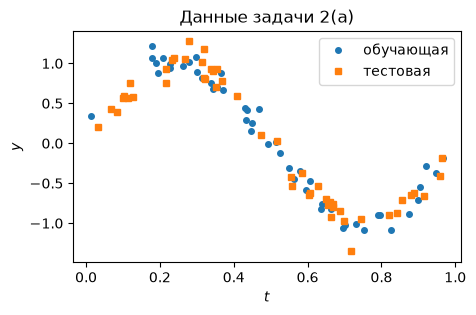

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

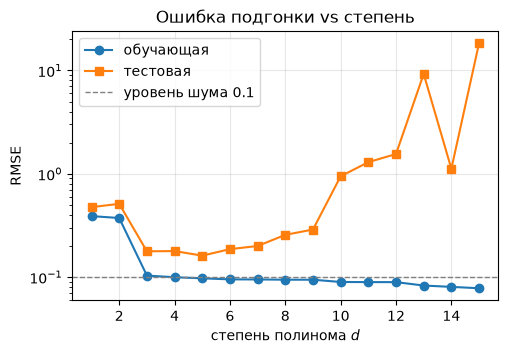

минимум тестовой ошибки при d = 5  RMSE_test = 0.1612


In [4]:
degrees = np.arange(1, 16)
rmse_train, rmse_test = [], []
for d in degrees:
    A_train = np.vander(t_train, d + 1, increasing=True)
    x, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)
    A_test = np.vander(t_test, d + 1, increasing=True)
    rmse_train.append(np.sqrt(np.mean((A_train @ x - y_train) ** 2)))
    rmse_test.append(np.sqrt(np.mean((A_test @ x - y_test) ** 2)))

plt.figure(figsize=(5.5, 3.5))
plt.semilogy(degrees, rmse_train, "o-", label="обучающая")
plt.semilogy(degrees, rmse_test, "s-", label="тестовая")
plt.axhline(0.1, color="gray", ls="--", lw=1, label="уровень шума 0.1")
plt.xlabel("степень полинома $d$"); plt.ylabel("RMSE"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Ошибка подгонки vs степень")
plt.show()

best = degrees[int(np.argmin(rmse_test))]
print("минимум тестовой ошибки при d =", best, " RMSE_test = %.4f" % min(rmse_test))

**Ответ (а).** Ошибка на обучающей выборке **монотонно не возрастает** с ростом $d$: полином степени $d$ — частный случай полинома степени $d+1$ (с нулевым старшим коэффициентом), а МНК находит наилучший в классе, поэтому расширение класса не может ухудшить подгонку. Тестовая ошибка сначала быстро падает (при $d = 1, 2$ модель слишком проста для синуса), достигает минимума около $d \approx 3$–$7$ на уровне шума $\approx 0.1$, а затем растёт: полином высокой степени начинает описывать шум обучающей выборки, который на тестовой другой. Это **переобучение**. Наблюдение: у обучающей кривой при больших $d$ значения могут слегка скакать — это уже влияние обусловленности матрицы Вандермонда, а не математики МНК.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
def solve_diet(b):
    res = linprog(c, A_ub=-A, b_ub=-b, bounds=(0, None), method="highs")
    assert res.success, res.message
    x = res.x
    active_nutr = np.abs(A @ x - b) < 1e-9
    active_x = np.abs(x) < 1e-9
    print("x* =", x.round(4), "  стоимость = %.4f" % res.fun)
    print("   активны требования по веществам:", np.where(active_nutr)[0] + 1,
          "  активны x_j >= 0 для j =", np.where(active_x)[0] + 1)
    return res

r0 = solve_diet(b)
r1 = solve_diet(b + np.array([1.0, 0.0, 0.0]))
print("изменение стоимости при b_1 -> b_1 + 1: %.4f" % (r1.fun - r0.fun))

x* = [ 2.  4. -0.  0.]   стоимость = 16.0000
   активны требования по веществам: [1 2 3]   активны x_j >= 0 для j = [3 4]
x* = [1.8889 3.5556 0.     0.6667]   стоимость = 17.1111
   активны требования по веществам: [1 2 3]   активны x_j >= 0 для j = [3]
изменение стоимости при b_1 -> b_1 + 1: 1.1111


**Ответ (б).** Решение $x^\ast = (2, 4, 0, 0)$: покупаем только продукты 1 и 2, стоимость $16$. Активны **все три** требования по веществам ($Ax^\ast = b$ точно) и два ограничения $x_3 \ge 0$, $x_4 \ge 0$ — всего пять активных ограничений при четырёх переменных. Это **вырожденная** вершина: через неё проходит «лишняя» грань; на классификацию решения это не влияет, но для алгоритмов (симплекс, лекция 11) вырожденность — источник хлопот.

При $b_1 \to 11$ решение меняется: $x^\ast \approx (1.889, 3.556, 0, 0.667)$, в рацион входит продукт 4, стоимость растёт до $17.111$, то есть на $1.111$. Требование 1 было активно, поэтому его ужесточение стоит денег; набор активных ограничений изменился ($x_4 \ge 0$ больше не активно). Если бы мы ужесточили *неактивное* ограничение (у которого есть запас), ни решение, ни стоимость не изменились бы. Коэффициент $1.111$ — «цена» единицы первого вещества; на лекции 3 узнаем, что это множитель Лагранжа.